In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import sys

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))

from gamma.artifacts import ArtifactStore
from gamma.mle import fit_mle_poisson, to_mle_estimate

In [2]:
### For Viz
#Default plot parameters
pltmap = plt.get_cmap("tab10")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linestyle'] = ':'
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

In [3]:
# store = ArtifactStore("../artifacts")   # or wherever your root is

store = ArtifactStore(repo_root / "artifacts")

Keeping track of labels defined in other notebook:

"Experiments"
- `ANIL_MIX_SD__agg__bkgsub`
- `ANIL_AC_SD__agg__bkgsub`
- `WENJO_CE_SD__agg__bkgsub__nobkgrows`
- `ANIL_CE_SD__agg__bkgsub`

"Cal tag"

- `'peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1'` Anil Ce-134, Wenjo Ce-134, Anil Ac-225 and Anil Mix all had the same cal_tag

Efficiency curve

- `"ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1"` just Anil Ce-134
- `"ce134_wenjoSD_resp_200-1250keV_cpm_nCi_np_v1"` just Wenjo Ce-134
- `"ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1"` just Anil Ac-225
- `"ce134_resp_200-1250keV_cpm_nCi_np_v1"` Wenjo + Anil Ce-134

# 1. Load Experiments and Calibrations

In [4]:
anil_ce_exp_id  = "ANIL_CE_SD__agg__bkgsub"
anil_ac_exp_id  = "ANIL_AC_SD__agg__bkgsub"
anil_mix_exp_id = "ANIL_MIX_SD__agg__bkgsub"

cal_tag = "peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1"

anil_ce_cal  = store.load_calibration(anil_ce_exp_id, cal_tag)
anil_ac_cal  = store.load_calibration(anil_ac_exp_id, cal_tag)
anil_mix_cal = store.load_calibration(anil_mix_exp_id, cal_tag)

# 2. Choose Templates for MLE

In [5]:
ce_template_label = anil_ce_cal.labels[2]
print(f'Ce template: {ce_template_label} nCi')
ac_template_label = anil_ac_cal.labels[5]
print(f'Ac template: {ac_template_label} nCi')

ce_template = anil_ce_cal.calibrated[ce_template_label]
ac_template = anil_ac_cal.calibrated[ac_template_label]

Ce template: 125 nCi
Ac template: 3.90625 nCi


# 3. Load Efficiency Models (Activity-to-Detector Response)

In [6]:
ce_eff_name = "ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1"
ac_eff_name = "ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1"

ce_eff = store.load_efficiency_model(ce_eff_name)
ac_eff = store.load_efficiency_model(ac_eff_name)

# 4. Load Input Spectrum
- Load mixed spectrum on which we will perform MLE on

In [7]:
mix_label = anil_mix_cal.labels[1]
print(f'Mixed spectrum input (ce:ac): {mix_label} nCi')
mix_spec = anil_mix_cal.calibrated[mix_label]

Mixed spectrum input (ce:ac): 125:3.906 nCi


# 5. Run MLE
- Define MLE config to track provenance and MLE parameters
- Run MLE with `fit_mle_poisson`
- Return estimate with `to_mle_estimate`

In [8]:
# ---- Run config (THIS is now the stable provenance) ----
mle_config = {
    "method": "poisson_mle_v1",
    "roi_keV": [200, 1250],
    "activity_units": "nci",
    "templates": {
        "ce134": {"experiment_id": anil_ce_exp_id, "cal_tag": cal_tag, "label": ce_template_label},
        "ac225": {"experiment_id": anil_ac_exp_id, "cal_tag": cal_tag, "label": ac_template_label},
    },
    "eff_models": {
        "ce134": ce_eff_name,
        "ac225": ac_eff_name,
    },
    # optional: include fit settings if they matter
    "fit_settings": {"method": "L-BFGS-B"},
}

run_id = ArtifactStore.make_run_id(mle_config, prefix="mle_poisson_v1")

fit2 = fit_mle_poisson(
    mix_spec,
    templates={"ce134": ce_template, "ac225": ac_template},
    eff_models={"ce134": ce_eff, "ac225": ac_eff},
    emin_keV=200, emax_keV=1250,
    activity_units="nci",
)

est2 = to_mle_estimate(
    fit2,
    experiment_id=anil_mix_exp_id,
    label=mix_label,
    activity_units="nci",
    run_config=mle_config,
)

# 6. Visualize MLE Result

C:\Users\pomar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


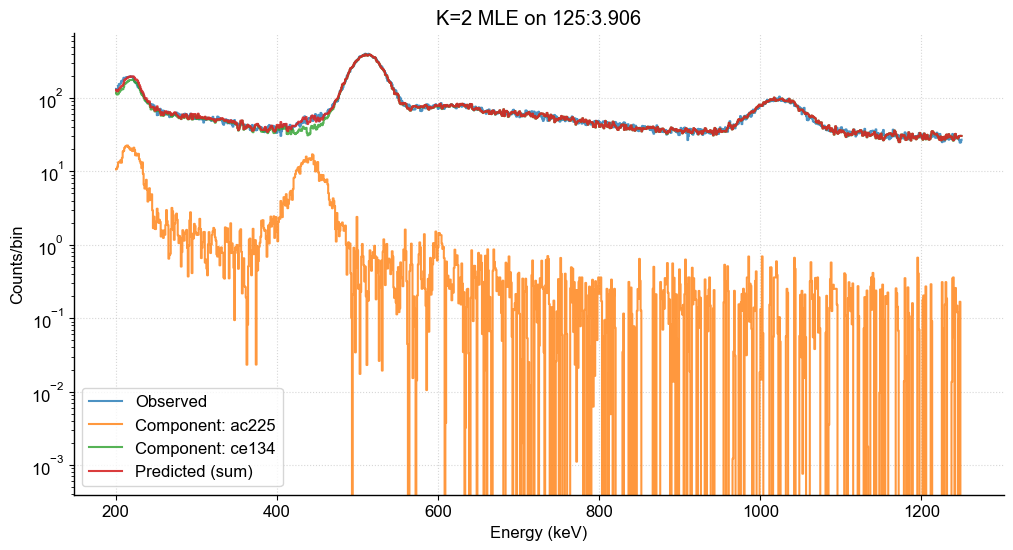

K=2 activities: {'ac225': 4.83097638175017, 'ce134': 119.51124510732893}
K=2 sigmas: {'ac225': 0.25718171721137756, 'ce134': 0.3385598324267449}


In [9]:
# Plot K=2 (components + sum)
plt.figure()
plt.step(fit2.x_keV, fit2.y_obs, where="mid", label="Observed", alpha=0.8)
for k, comp in fit2.components_hat.items():
    plt.step(fit2.x_keV, comp, where="mid", label=f"Component: {k}", alpha=0.8)
plt.step(fit2.x_keV, fit2.y_hat, where="mid", label="Predicted (sum)", alpha=0.9)
plt.yscale("log")
plt.xlabel("Energy (keV)")
plt.ylabel("Counts/bin")
plt.legend()
plt.title(f"K=2 MLE on {mix_label}")
plt.show()

print("K=2 activities:", fit2.activities)
print("K=2 sigmas:", fit2.sigma_activities)

# 7. Save MLE Result

In [10]:
store.save_mle_estimate(est2, run_id=run_id, fit_arrays=fit2)

print("Saved MLE:", anil_mix_exp_id, mix_label, run_id)

Saved MLE: ANIL_MIX_SD__agg__bkgsub 125:3.906 mle_poisson_v1__98cc2e1f0a


# Loop (Run MLE en Masse)
- Here, we'll hold the Efficiency Models constant and loop through templates 
- Basically, Steps 1., 2., 4., 5., 7. will be in the loop
- Do Step 3. (Defining Efficiency Models) outside the loop 
- Skip Step 6. (Visualize), will bog down compute

*Note for this loop:*
- The Ce efficiency model is `ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1`, which is NOT the merged Ce efficiency!
- The Ac efficiency model is `ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1`
- Looping over Anil mixed samples and performing MLE using all permutations of pure Ac-225 and Ce-134 spectrum templates from Anil's SDs.

In [11]:
cal_tag = "peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1"

anil_ce_exp_id  = "ANIL_CE_SD__agg__bkgsub" 
anil_ac_exp_id  = "ANIL_AC_SD__agg__bkgsub"
anil_mix_exp_id = "ANIL_MIX_SD__agg__bkgsub"

ce_eff_name = "ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1"
ac_eff_name = "ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1"

anil_ce_cal  = store.load_calibration(anil_ce_exp_id, cal_tag)
anil_ac_cal  = store.load_calibration(anil_ac_exp_id, cal_tag)
anil_mix_cal = store.load_calibration(anil_mix_exp_id, cal_tag)

ce_eff = store.load_efficiency_model(ce_eff_name)
ac_eff = store.load_efficiency_model(ac_eff_name)

ce_labels  = list(anil_ce_cal.labels)
ac_labels  = list(anil_ac_cal.labels)
mix_labels = list(anil_mix_cal.labels)

for mix_label in mix_labels:
    mix_spec = anil_mix_cal.calibrated[mix_label]

    for ce_template_label in ce_labels:
        ce_template = anil_ce_cal.calibrated[ce_template_label]

        for ac_template_label in ac_labels:
            ac_template = anil_ac_cal.calibrated[ac_template_label]

            mle_config = {
                "method": "poisson_mle_v1",
                "roi_keV": [200, 1250],
                "activity_units": "nci",
                "templates": {
                    "ce134": {"experiment_id": anil_ce_exp_id, "cal_tag": cal_tag, "label": ce_template_label},
                    "ac225": {"experiment_id": anil_ac_exp_id, "cal_tag": cal_tag, "label": ac_template_label},
                },
                "eff_models": {
                    "ce134": ce_eff_name,
                    "ac225": ac_eff_name,
                },
            }

            run_id = ArtifactStore.make_run_id(mle_config, prefix="mle_poisson_v1")

            # Optional: skip if already computed
            # This matches your on-disk layout: artifacts/mle/<exp>/<label>/<run_id>.json
            out_json = store._mle_sample_dir(anil_mix_exp_id, mix_label) / f"{run_id}.json"
            if out_json.exists():
                print('.json already exists for this config, as expected.')
                continue

            fit = fit_mle_poisson(
                mix_spec,
                templates={"ce134": ce_template, "ac225": ac_template},
                eff_models={"ce134": ce_eff, "ac225": ac_eff},
                emin_keV=200, emax_keV=1250,
                activity_units="nci",
            )

            est = to_mle_estimate(
                fit,
                experiment_id=anil_mix_exp_id,
                label=mix_label,
                activity_units="nci",
                run_config=mle_config,
            )

            store.save_mle_estimate(est, run_id=run_id, fit_arrays=fit)


.json already exists for this config, as expected.
.json already exists for this config, as expected.
.json already exists for this config, as expected.
.json already exists for this config, as expected.
.json already exists for this config, as expected.
.json already exists for this config, as expected.
.json already exists for this config, as expected.
.json already exists for this config, as expected.
.json already exists for this config, as expected.
.json already exists for this config, as expected.
.json already exists for this config, as expected.
.json already exists for this config, as expected.
.json already exists for this config, as expected.
.json already exists for this config, as expected.
.json already exists for this config, as expected.
.json already exists for this config, as expected.
.json already exists for this config, as expected.
.json already exists for this config, as expected.
.json already exists for this config, as expected.
.json already exists for this c

# Loop 2
- Looping over Anil mixed samples and performing MLE using all permutations of pure Ac-225 and Ce-134 spectrum templates from Anil's SDs.
- The Ce efficiency model is `ce134_resp_200-1250keV_cpm_nCi_np_v1`, which IS the merged Ce efficiency!
- The Ac efficiency model is `ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1`

In [12]:
cal_tag = "peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1"

anil_ce_exp_id  = "ANIL_CE_SD__agg__bkgsub" 
anil_ac_exp_id  = "ANIL_AC_SD__agg__bkgsub"
anil_mix_exp_id = "ANIL_MIX_SD__agg__bkgsub"

ce_eff_name = "ce134_resp_200-1250keV_cpm_nCi_np_v1"
ac_eff_name = "ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1"

anil_ce_cal  = store.load_calibration(anil_ce_exp_id, cal_tag)
anil_ac_cal  = store.load_calibration(anil_ac_exp_id, cal_tag)
anil_mix_cal = store.load_calibration(anil_mix_exp_id, cal_tag)

ce_eff = store.load_efficiency_model(ce_eff_name)
ac_eff = store.load_efficiency_model(ac_eff_name)

ce_labels  = list(anil_ce_cal.labels)
ac_labels  = list(anil_ac_cal.labels)
mix_labels = list(anil_mix_cal.labels)

for mix_label in mix_labels:
    mix_spec = anil_mix_cal.calibrated[mix_label]

    for ce_template_label in ce_labels:
        ce_template = anil_ce_cal.calibrated[ce_template_label]

        for ac_template_label in ac_labels:
            ac_template = anil_ac_cal.calibrated[ac_template_label]

            mle_config = {
                "method": "poisson_mle_v1",
                "roi_keV": [200, 1250],
                "activity_units": "nci",
                "templates": {
                    "ce134": {"experiment_id": anil_ce_exp_id, "cal_tag": cal_tag, "label": ce_template_label},
                    "ac225": {"experiment_id": anil_ac_exp_id, "cal_tag": cal_tag, "label": ac_template_label},
                },
                "eff_models": {
                    "ce134": ce_eff_name,
                    "ac225": ac_eff_name,
                },
            }

            run_id = ArtifactStore.make_run_id(mle_config, prefix="mle_poisson_v1")

            # Optional: skip if already computed
            # This matches your on-disk layout: artifacts/mle/<exp>/<label>/<run_id>.json
            out_json = store._mle_sample_dir(anil_mix_exp_id, mix_label) / f"{run_id}.json"
            if out_json.exists():
                continue

            fit = fit_mle_poisson(
                mix_spec,
                templates={"ce134": ce_template, "ac225": ac_template},
                eff_models={"ce134": ce_eff, "ac225": ac_eff},
                emin_keV=200, emax_keV=1250,
                activity_units="nci",
            )

            est = to_mle_estimate(
                fit,
                experiment_id=anil_mix_exp_id,
                label=mix_label,
                activity_units="nci",
                run_config=mle_config,
            )

            store.save_mle_estimate(est, run_id=run_id, fit_arrays=fit)


c:\Users\pomar\OneDrive\Desktop\Hidex_AcCe_July2_Wenjo_Project\12-23-2025\gamma_pipeline\gamma\mle.py:199: RuntimeWarning: divide by zero encountered in log
  term = mu - y + np.where(y > 0, y * np.log(y / mu), 0.0)
c:\Users\pomar\OneDrive\Desktop\Hidex_AcCe_July2_Wenjo_Project\12-23-2025\gamma_pipeline\gamma\mle.py:199: RuntimeWarning: invalid value encountered in multiply
  term = mu - y + np.where(y > 0, y * np.log(y / mu), 0.0)


In [13]:
end

NameError: name 'end' is not defined

# Load Experiments and Calibrations

In [ ]:
# ---- Load calibrated spectra ----
anil_ce_exp_id = "ANIL_CE_SD__agg__bkgsub"
wenjo_ce_exp_id = "WENJO_CE_SD__agg__bkgsub__nobkgrows"
anil_ac_exp_id = "ANIL_AC_SD__agg__bkgsub"
anil_mix_exp_id = "ANIL_MIX_SD__agg__bkgsub"

cal_tag = "peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1"

anil_ce_cal = store.load_calibration(anil_ce_exp_id, cal_tag)
anil_ac_cal = store.load_calibration(anil_ac_exp_id, cal_tag)
anil_mix_cal = store.load_calibration(anil_mix_exp_id, cal_tag)

# Choose Templates and Input Spectrum

In [ ]:
# ---- Pick which calibrated spectra become "templates" ----
# Use any label you want (you can sweep later). Here: just pick the first label.
ce_template_label = anil_ce_cal.labels[2]
ac_template_label = anil_ac_cal.labels[5]

print('Ce template', 'Ac template', ce_template_label, ac_template_label)

ce_template = anil_ce_cal.calibrated[ce_template_label]  # bq_v1-like spectrum
ac_template = anil_ac_cal.calibrated[ac_template_label]


Ce template Ac template 125 3.90625


In [ ]:
# ---- Load efficiency models (names should match what you saved in 03_efficiency.ipynb) ----
ce_eff_name = "ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1"
ac_eff_name = "ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1"
ce_eff = store.load_efficiency_model(ce_eff_name)
ac_eff = store.load_efficiency_model(ac_eff_name)


In [ ]:
# ---- Choose a mixed spectrum label to fit ----
mix_label = anil_mix_cal.labels[1]
mix_spec = anil_mix_cal.calibrated[mix_label]

# Single Isotope Activity Estimation: MLE, k=1

In [ ]:
# ---- K=1 fit (example: pretend mix_spec is single-isotope, or use a true single-isotope spectrum) ----
fit1 = fit_mle_poisson(
    ce_template,
    templates={"ce134": ce_template},
    eff_models={"ce134": ce_eff},
    emin_keV=200, emax_keV=1250,
    activity_units="nci",   # must match how your efficiency models were fit
)

C:\Users\pomar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


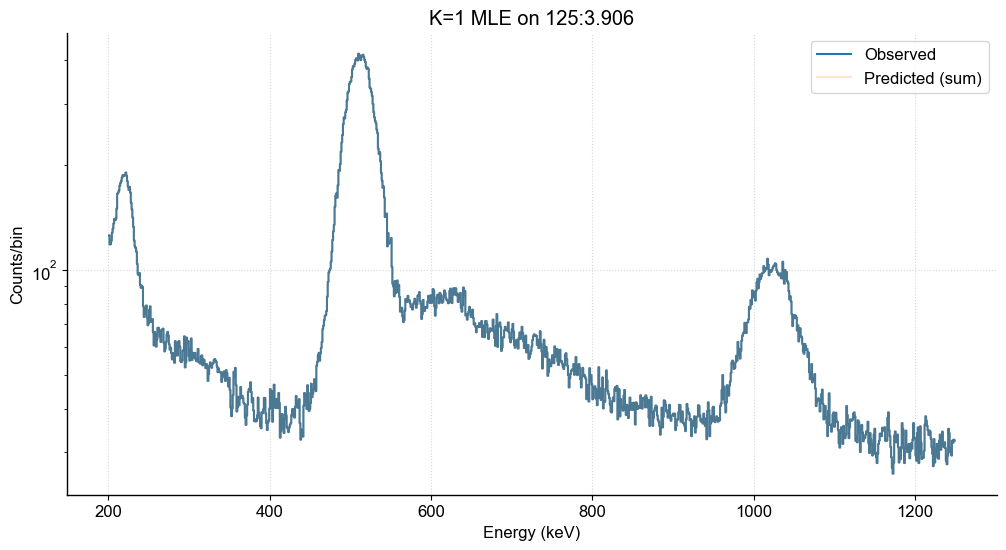

K=1 activities: {'ce134': 127.70252272933477}
K=1 sigmas: {'ce134': 0.32104344438224314}


In [ ]:
# Plot K=1
plt.figure()
plt.step(fit1.x_keV, fit1.y_obs, where="mid", label="Observed")
plt.step(fit1.x_keV, fit1.y_hat, where="mid", label="Predicted (sum)", alpha= 0.2)
plt.yscale("log")
plt.xlabel("Energy (keV)")
plt.ylabel("Counts/bin")
plt.legend()
plt.title(f"K=1 MLE on {mix_label}")
plt.show()

print("K=1 activities:", fit1.activities)
print("K=1 sigmas:", fit1.sigma_activities)


# Mixed Isotope Activity Estimation: MLE, k=2

In [ ]:
mle_config = {
    "method": "poisson_mle_v1",
    "roi_keV": [200, 1250],
    "activity_units": "nci",
    "templates": {
        "ce134": {"experiment_id": anil_ce_exp_id, "cal_tag": cal_tag, "label": ce_template_label},
        "ac225": {"experiment_id": anil_ac_exp_id, "cal_tag": cal_tag, "label": ac_template_label},
    },
    "eff_models": {
        "ce134": ce_eff_name,
        "ac225": ac_eff_name,
    },
}

run_id = ArtifactStore.make_run_id(mle_config)

In [ ]:
# ---- K=2 fit (Ac + Ce) ----
fit2 = fit_mle_poisson(
    mix_spec,
    templates={"ce134": ce_template, "ac225": ac_template},
    eff_models={"ce134": ce_eff, "ac225": ac_eff},
    emin_keV=200, emax_keV=1250,
    activity_units="nci",
)

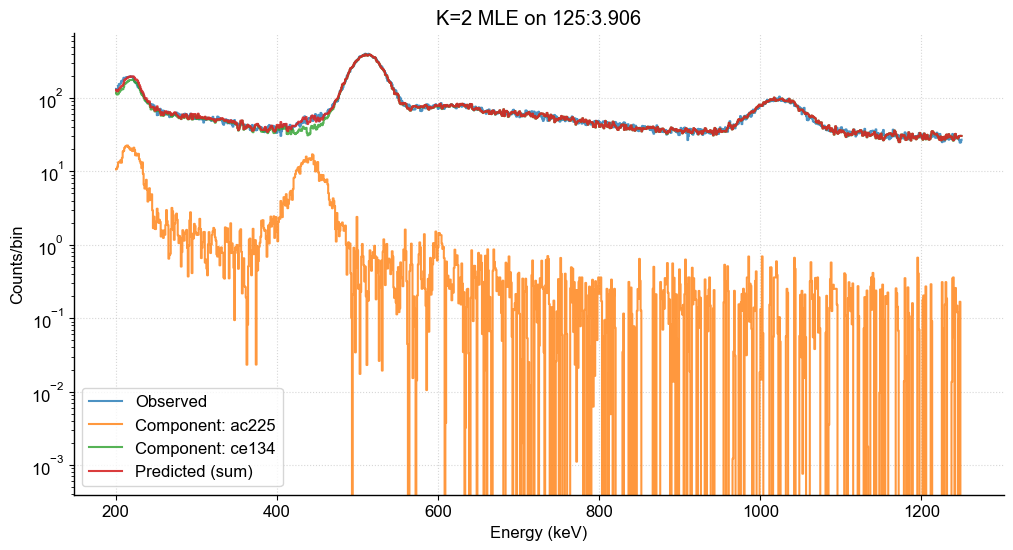

K=2 activities: {'ac225': 4.83097638175017, 'ce134': 119.51124510732893}
K=2 sigmas: {'ac225': 0.25718171721137756, 'ce134': 0.3385598324267449}


In [ ]:
# Plot K=2 (components + sum)
plt.figure()
plt.step(fit2.x_keV, fit2.y_obs, where="mid", label="Observed", alpha=0.8)
for k, comp in fit2.components_hat.items():
    plt.step(fit2.x_keV, comp, where="mid", label=f"Component: {k}", alpha=0.8)
plt.step(fit2.x_keV, fit2.y_hat, where="mid", label="Predicted (sum)", alpha=0.9)
plt.yscale("log")
plt.xlabel("Energy (keV)")
plt.ylabel("Counts/bin")
plt.legend()
plt.title(f"K=2 MLE on {mix_label}")
plt.show()

print("K=2 activities:", fit2.activities)
print("K=2 sigmas:", fit2.sigma_activities)

In [ ]:
# ---- Save as an artifact (optional) ----
est2 = to_mle_estimate(
    fit2,
    experiment_id=anil_mix_exp_id,
    label=mix_label,
    activity_units="nci",
    extra_diagnostics=mle_config,
)
# store.save_mle_estimate(est2)
store.save_mle_estimate(est2, run_id=run_id)

In [ ]:
end

NameError: name 'end' is not defined

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from gamma.artifacts import ArtifactStore
from gamma.mle import run_mle

store = ArtifactStore("../artifacts")

cal = store.load_calibration("ANIL_MIX", "peakfit_v2_emin120_emax2000")
eff = store.load_efficiency_model("detector_v2")

result = run_mle(cal, eff, ...)  # we’ll implement this soon
store.save_mle_estimate(result)


In [ ]:
model = store.load_efficiency_model("Ce134_resp_511to1700_v1")


In [ ]:
R_pred = evaluate_efficiency_model(model, A_bq)


In [ ]:
x_mix = mix_spec["bin_centers_kev"]
x_ce  = ce_template["bin_centers_kev"]
x_ac  = ac_template["bin_centers_kev"]

print(len(x_mix), len(x_ce), len(x_ac))
print(x_mix[:3], x_ce[:3], x_ac[:3])
print("x grids equal?", np.allclose(x_mix, x_ce), np.allclose(x_mix, x_ac))

def span(x):
    return float(np.min(x)), float(np.max(x))

for name, spec in [("mix", mix_spec), ("ce", ce_template), ("ac", ac_template)]:
    x = np.asarray(spec["bin_centers_kev"])
    print(name, span(x))